In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv('ToyotaCorolla - MLR.csv')

In [3]:
df.shape

(1436, 11)

In [4]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [41]:
df['Fuel_Type'].unique()

array(['Diesel', 'Petrol', 'CNG'], dtype=object)

In [4]:
df = df.rename(columns={'Age_08_04':'Age'})
df.head()

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [62]:
df.isnull().sum()

Price        0
Age          0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [63]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.drop_duplicates(inplace=True)

In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df.describe()

,Price,Age,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1435.000000,1435.000000,1435.000000,1435.000000,1435.0,1435.000000,1435.000000,1435.0,1435.0,1435.000000
mean,10495.964460,55.992334,67644.520383,101.093380,0.0,1558.327526,4.032753,4.0,5.0,1068.520906
std,2977.598549,18.529725,34725.393258,13.146145,0.0,168.788311,0.952667,0.0,0.0,37.722708
min,4350.000000,5.000000,1.000000,69.000000,0.0,1300.000000,2.000000,4.0,5.0,1000.000000
25%,8450.000000,44.000000,43000.000000,90.000000,0.0,1400.000000,3.000000,4.0,5.0,1040.000000
50%,9900.000000,61.000000,63451.000000,110.000000,0.0,1600.000000,4.000000,4.0,5.0,1070.000000
75%,11950.000000,70.000000,87041.500000,110.000000,0.0,1600.000000,5.000000,4.0,5.0,1085.000000
max,17200.000000,80.000000,153103.750000,140.000000,0.0,1900.000000,5.000000,4.0,5.0,1152.500000


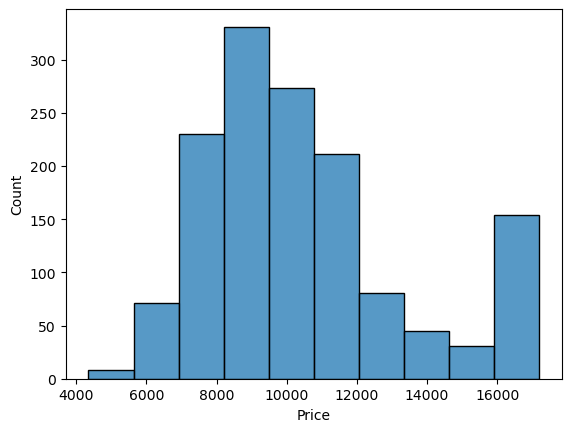

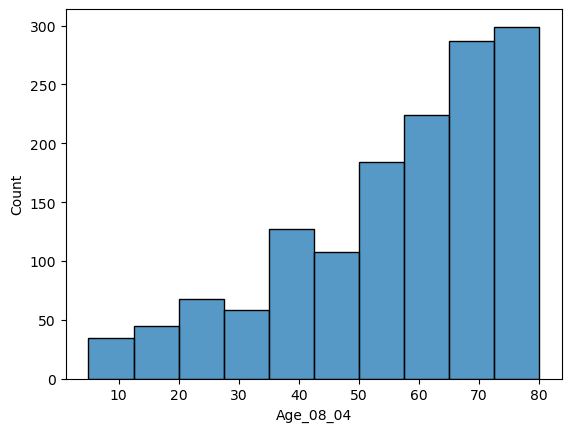

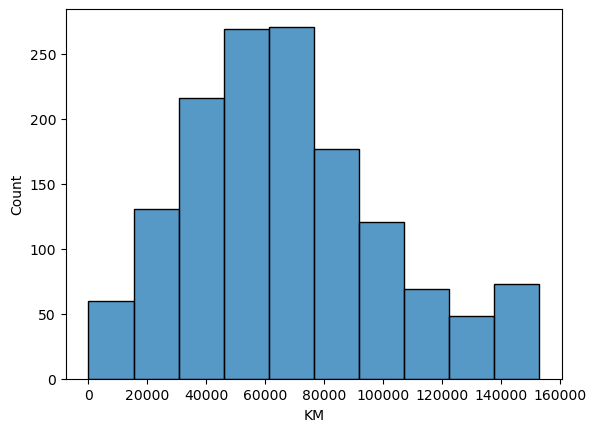

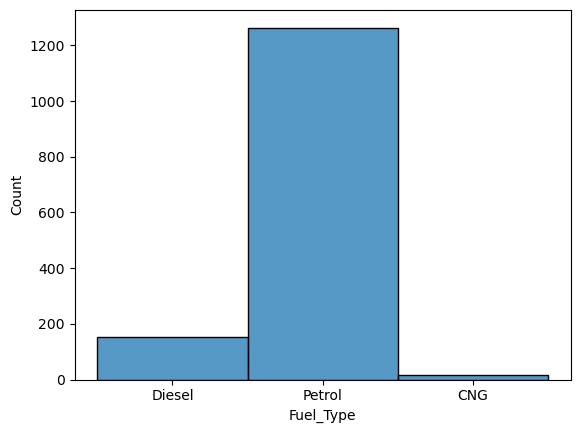

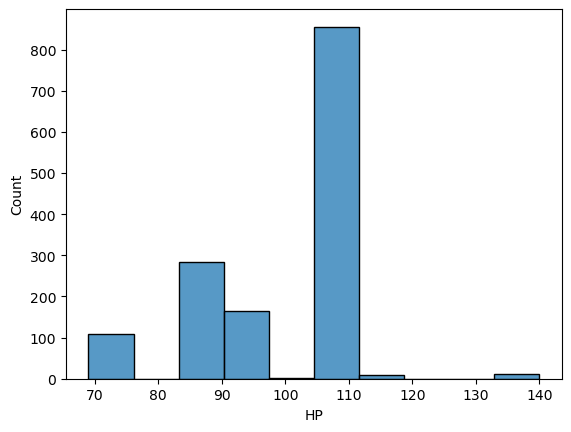

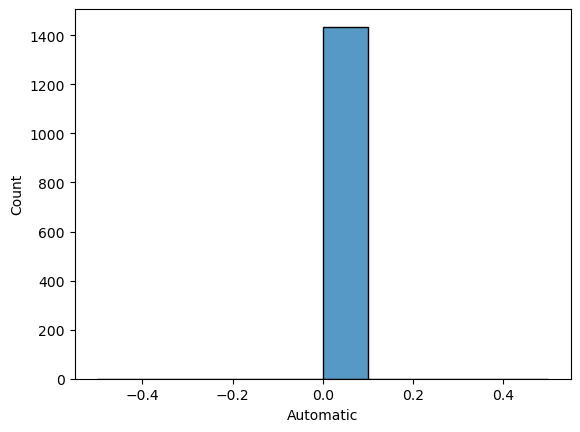

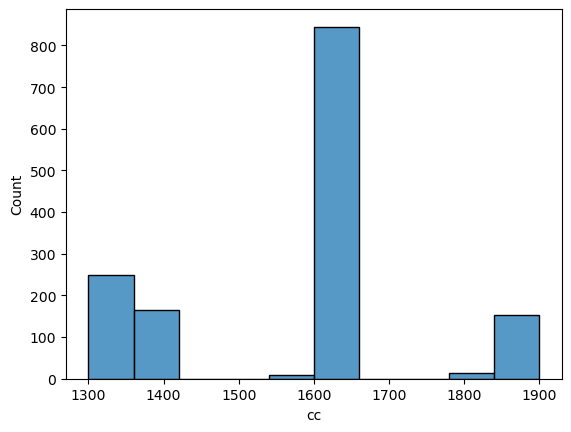

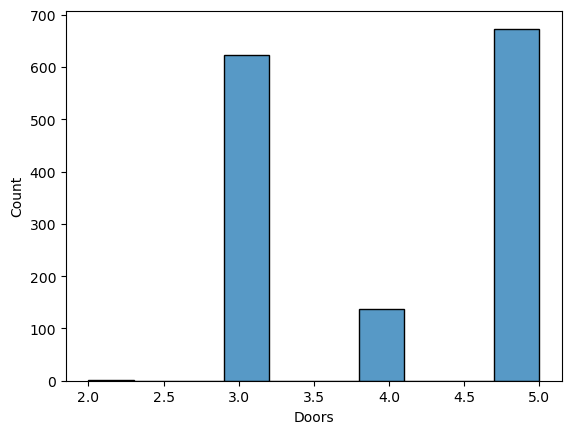

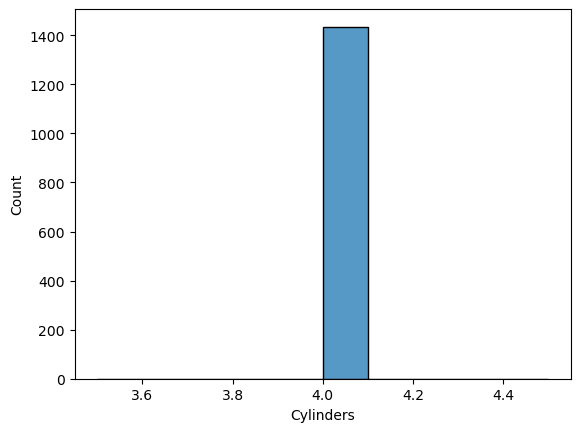

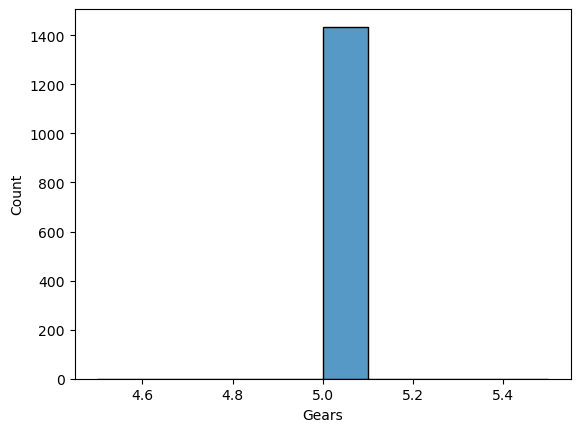

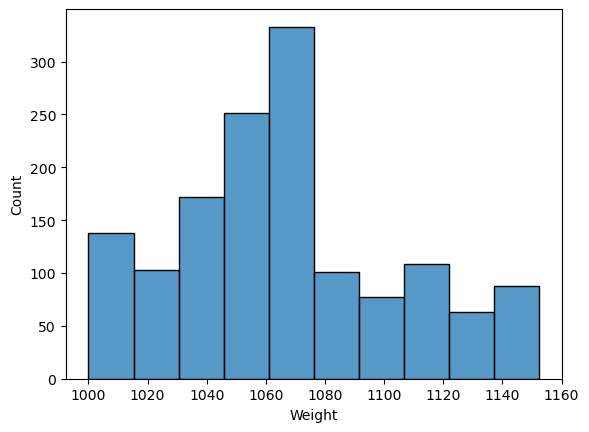

In [42]:
for col in df.columns:
    sns.histplot(df[col],bins=10)
    plt.show()

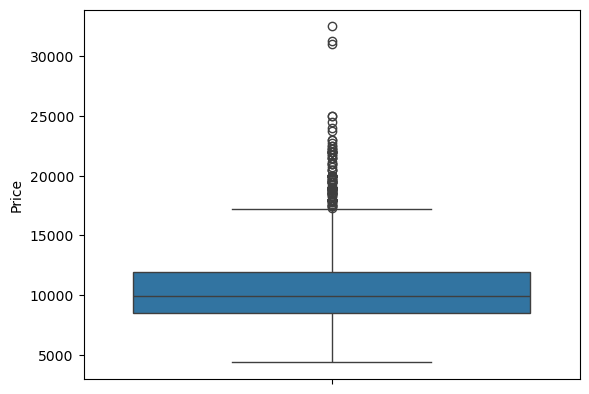

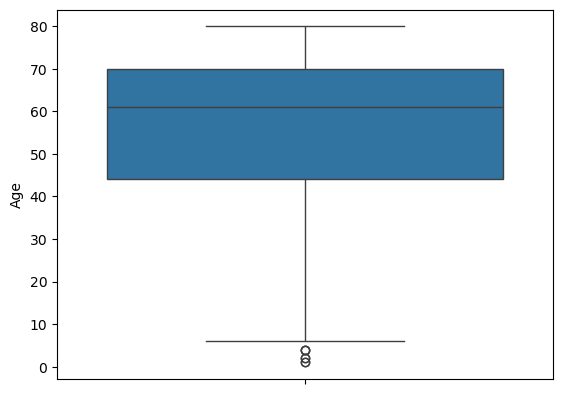

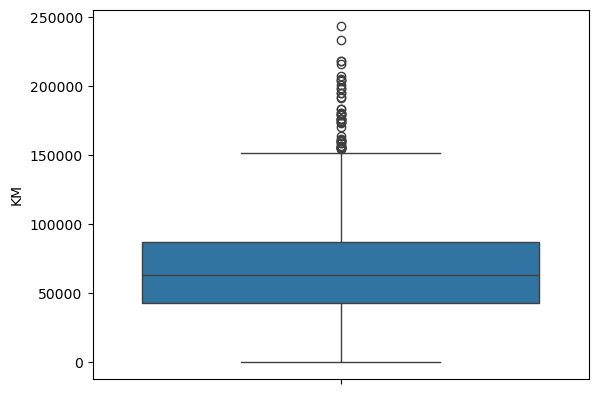

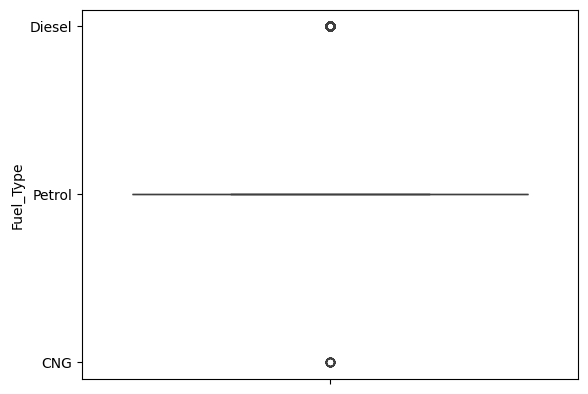

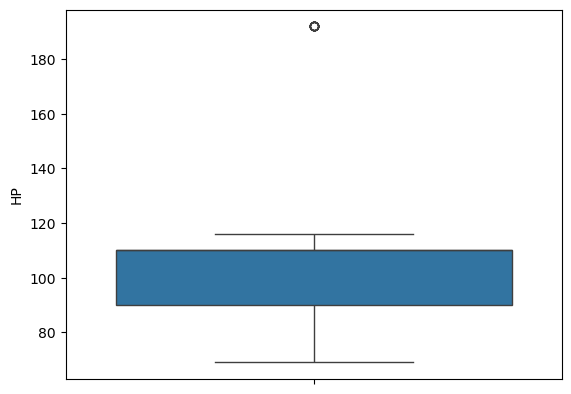

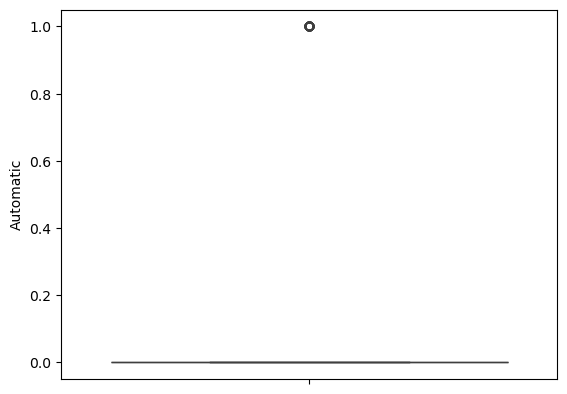

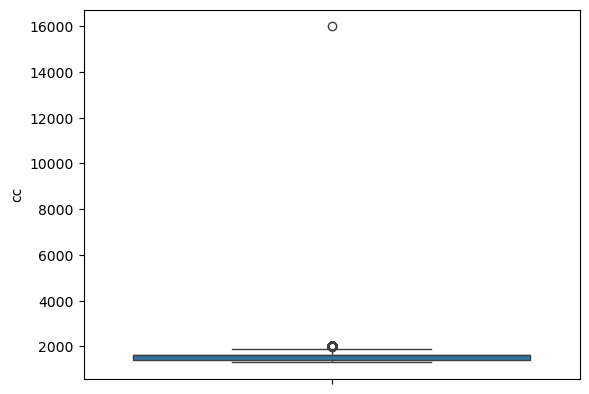

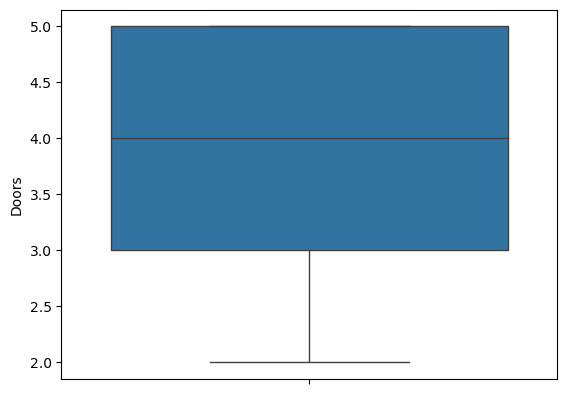

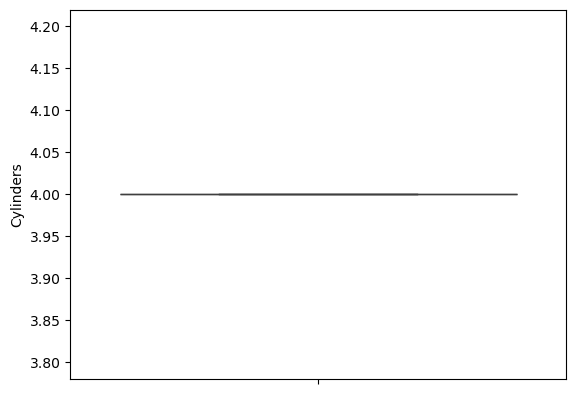

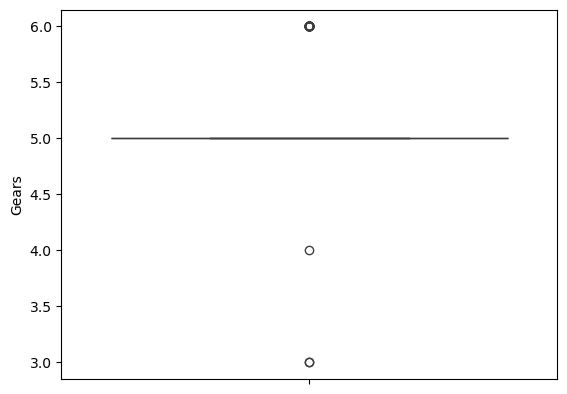

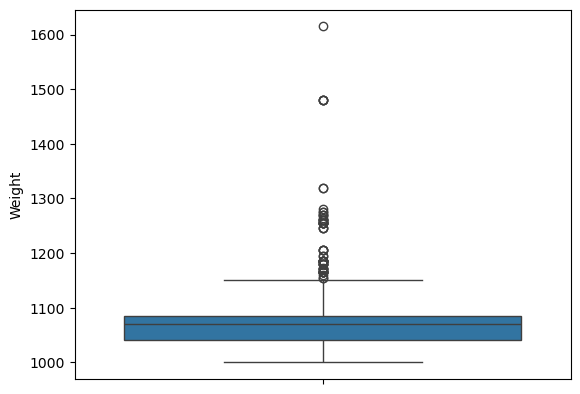

In [6]:
## Outlier detection
for col in df.columns:
    sns.boxplot(df[col])
    plt.show()

In [7]:
## Outlier Capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 -Q1
    lower_extreme = Q1 - 1.5*IQR
    upper_extreme = Q3 + 1.5*IQR
    df[columns] = df[columns].apply(lambda x:lower_extreme if x<lower_extreme else 
                                    upper_extreme if x> upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

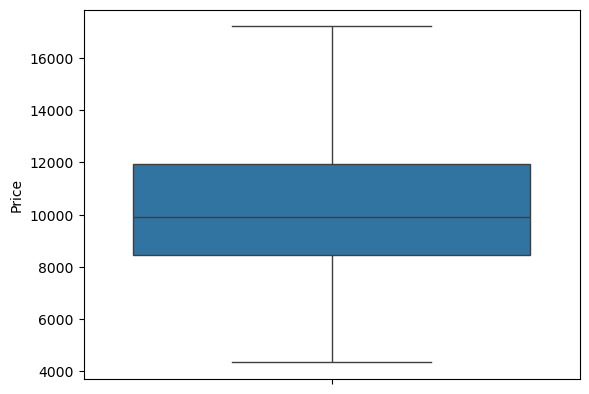

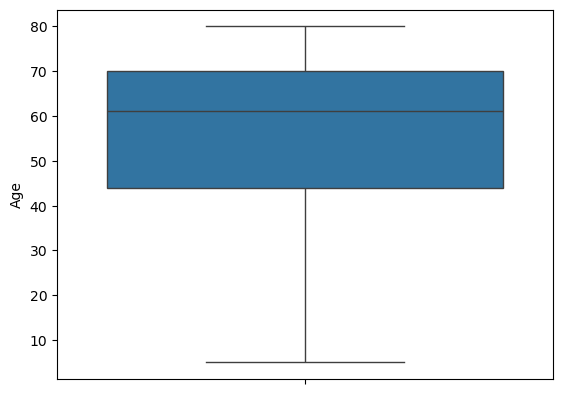

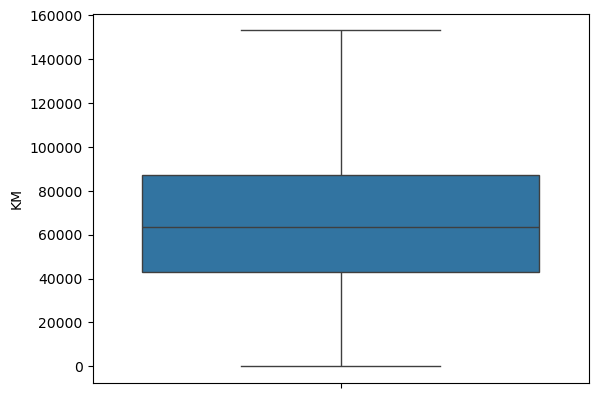

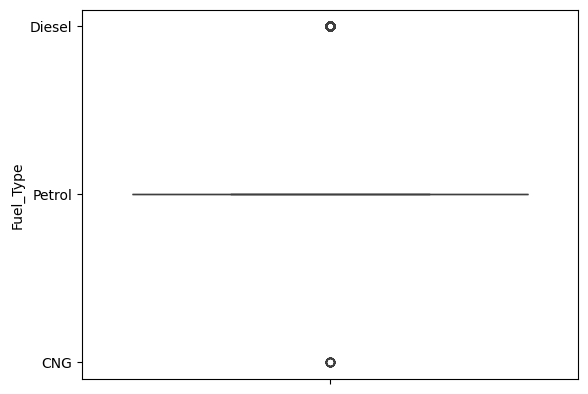

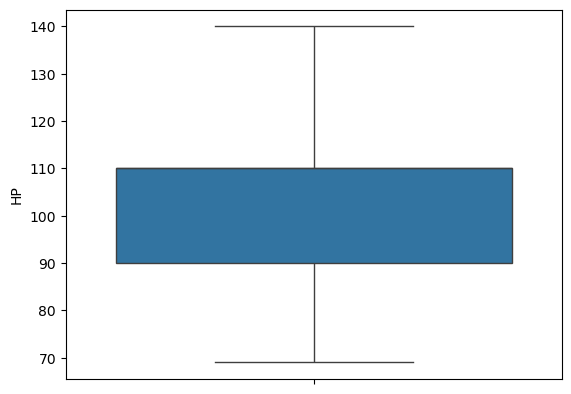

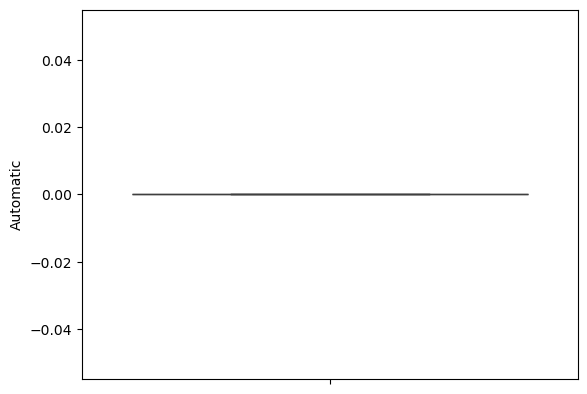

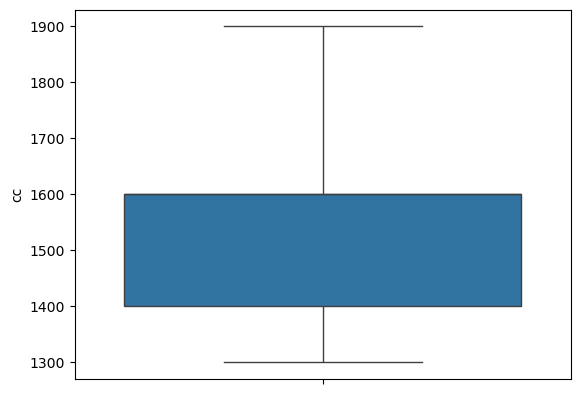

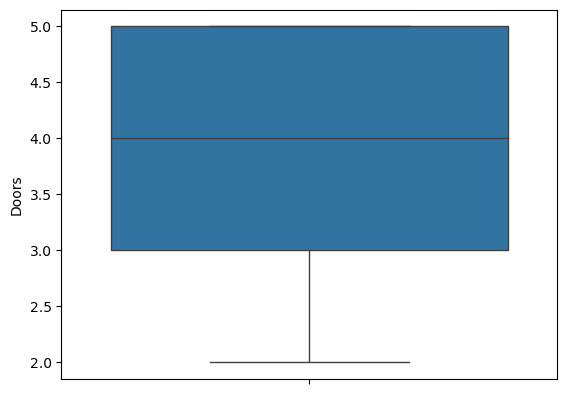

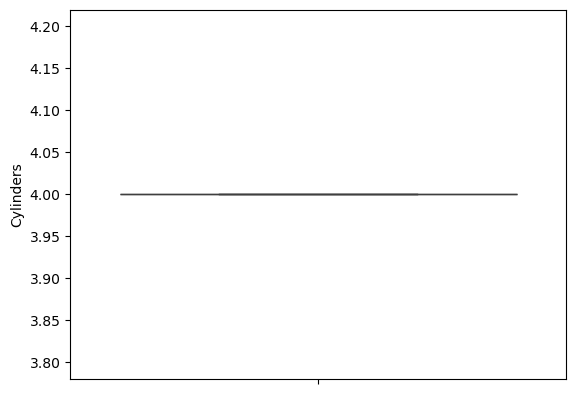

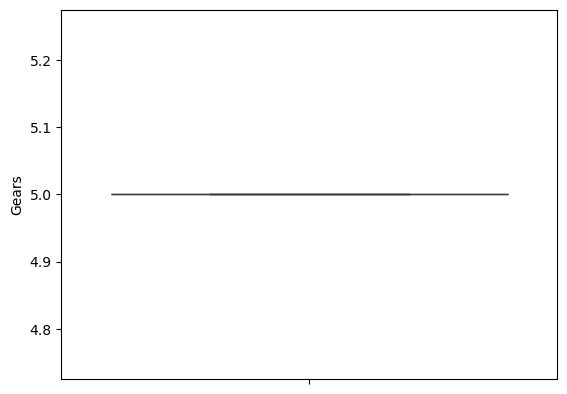

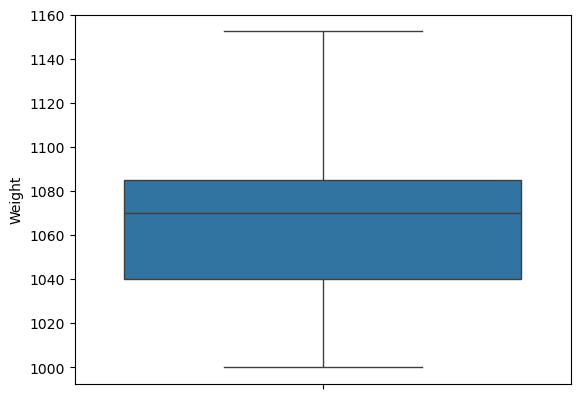

In [8]:
for col in df.columns:
    sns.boxplot(df[col])
    plt.show()

In [9]:
numeric = df.select_dtypes(include=['int','float'])
numeric

,Price,Age,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500.0,23.0,46986.0,90.0,0.0,1900.0,3,4,5.0,1152.5
1,13750.0,23.0,72937.0,90.0,0.0,1900.0,3,4,5.0,1152.5
2,13950.0,24.0,41711.0,90.0,0.0,1900.0,3,4,5.0,1152.5
3,14950.0,26.0,48000.0,90.0,0.0,1900.0,3,4,5.0,1152.5
4,13750.0,30.0,38500.0,90.0,0.0,1900.0,3,4,5.0,1152.5
...,...,...,...,...,...,...,...,...,...,...
1431,7500.0,69.0,20544.0,86.0,0.0,1300.0,3,4,5.0,1025.0
1432,10845.0,72.0,19000.0,86.0,0.0,1300.0,3,4,5.0,1015.0
1433,8500.0,71.0,17016.0,86.0,0.0,1300.0,3,4,5.0,1015.0
1434,7250.0,70.0,16916.0,86.0,0.0,1300.0,3,4,5.0,1015.0


In [10]:
target = df['Price']
features = df.drop(columns=['Price'])

In [75]:
target.head()

0    13500.0
1    13750.0
2    13950.0
3    14950.0
4    13750.0
Name: Price, dtype: float64

In [76]:
features.head()

,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,23.0,46986.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
1,23.0,72937.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
2,24.0,41711.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
3,26.0,48000.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
4,30.0,38500.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5


<Axes: >

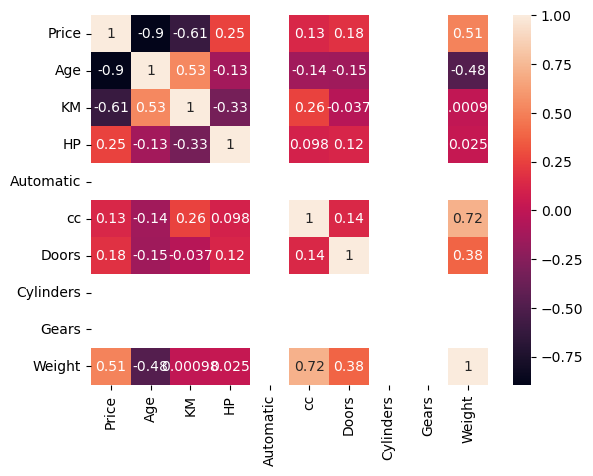

In [11]:
## Correlation
corr = numeric.corr()
sns.heatmap(corr,annot=True)

In [12]:
## feature selection - f- regression because target is continous
from sklearn.feature_selection import f_regression

In [13]:
features_num = df.select_dtypes(exclude=['object'])

In [14]:
f_reg = f_regression(features_num,target)
f_reg

(array([-3.22682913e+17,  5.79099779e+03,  8.40165852e+02,  9.91828244e+01,
         0.00000000e+00,  2.43847136e+01,  4.96579374e+01,  0.00000000e+00,
         0.00000000e+00,  4.97966391e+02]),
 array([1.00000000e+000, 0.00000000e+000, 9.19507250e-146, 1.22819794e-022,
        1.00000000e+000, 8.81431719e-007, 2.83450155e-012, 1.00000000e+000,
        1.00000000e+000, 6.45615931e-095]))

In [15]:
## Checking multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [16]:
vif = pd.DataFrame()
vif['features_num'] = features_num.columns
vif['VIF_score'] = [variance_inflation_factor(features_num.values,i)
                    for i in range(len(features_num.columns))]
vif

,features_num,VIF_score
0,Price,7.346613
1,Age,5.358279
2,KM,2.167375
3,HP,1.354444
4,Automatic,NaN
5,cc,2.956430
6,Doors,1.290231
7,Cylinders,0.000000
8,Gears,0.000000
9,Weight,4.348467


In [17]:
## Splitting the dataset into Train and Test
x_train,x_test,y_train,y_test = train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 10)
(287, 10)
(1148,)
(287,)


In [84]:
x_train.head()

,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
108,20.0,7187.0,Petrol,110.0,0.0,1600.0,3,4,5.0,1105.0
1280,78.0,73638.0,Petrol,86.0,0.0,1300.0,4,4,5.0,1015.0
858,62.0,64797.0,Petrol,110.0,0.0,1600.0,5,4,5.0,1075.0
903,65.0,59000.0,Petrol,110.0,0.0,1600.0,5,4,5.0,1075.0
373,33.0,16512.0,Petrol,97.0,0.0,1400.0,5,4,5.0,1085.0


In [18]:
## scaling
from sklearn.preprocessing import StandardScaler
std_sca = StandardScaler()
x_train[['Age','KM','HP','Automatic','cc','Doors','Cylinders','Gears','Weight']] = std_sca.fit_transform(x_train[['Age','KM','HP','Automatic','cc','Doors','Cylinders','Gears','Weight']])
x_train.head()

,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
108,-1.940533,-1.748188,Petrol,0.689004,0.0,0.255237,-1.074130,0.0,0.0,0.954608
1280,1.182405,0.176456,Petrol,-1.123604,0.0,-1.492799,-0.024682,0.0,0.0,-1.387370
858,0.320905,-0.079609,Petrol,0.689004,0.0,0.255237,1.024766,0.0,0.0,0.173948
903,0.482436,-0.247509,Petrol,0.689004,0.0,0.255237,1.024766,0.0,0.0,0.173948
373,-1.240564,-1.478104,Petrol,-0.292825,0.0,-0.910121,1.024766,0.0,0.0,0.434168


In [19]:
x_test[['Age','KM','HP','Automatic','cc','Doors','Cylinders','Gears','Weight']] = std_sca.transform(x_test[['Age','KM','HP','Automatic','cc','Doors','Cylinders','Gears','Weight']])
x_test.head()

,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
57,-1.617470,-0.710923,Petrol,-0.292825,0.0,-0.910121,1.024766,0.0,0.0,1.084718
1003,0.320905,-0.826777,Petrol,0.689004,0.0,0.255237,1.024766,0.0,0.0,0.173948
361,-1.132876,-1.260908,Petrol,-0.292825,0.0,-0.910121,-1.074130,0.0,0.0,-1.127151
904,0.267061,-0.247509,Petrol,0.689004,0.0,0.255237,1.024766,0.0,0.0,0.043838
1277,1.236249,0.189634,Petrol,0.689004,0.0,0.255237,1.024766,0.0,0.0,0.173948


In [20]:
## Labelling
from sklearn.preprocessing import OneHotEncoder
one_hot = OneHotEncoder()

In [21]:
## Even if i import OneHotEncoder i use pandas function get_dummies for quick output
x_train = pd.get_dummies(x_train,dtype='int')

In [92]:
x_train.head()

,Age,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
108,-1.940533,-1.748188,0.689004,0.0,0.255237,-1.074130,0.0,0.0,0.954608,0,0,1
1280,1.182405,0.176456,-1.123604,0.0,-1.492799,-0.024682,0.0,0.0,-1.387370,0,0,1
858,0.320905,-0.079609,0.689004,0.0,0.255237,1.024766,0.0,0.0,0.173948,0,0,1
903,0.482436,-0.247509,0.689004,0.0,0.255237,1.024766,0.0,0.0,0.173948,0,0,1
373,-1.240564,-1.478104,-0.292825,0.0,-0.910121,1.024766,0.0,0.0,0.434168,0,0,1


In [22]:
x_test = pd.get_dummies(x_test,dtype='int')
x_test.head()

,Age,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
57,-1.617470,-0.710923,-0.292825,0.0,-0.910121,1.024766,0.0,0.0,1.084718,0,0,1
1003,0.320905,-0.826777,0.689004,0.0,0.255237,1.024766,0.0,0.0,0.173948,0,0,1
361,-1.132876,-1.260908,-0.292825,0.0,-0.910121,-1.074130,0.0,0.0,-1.127151,0,0,1
904,0.267061,-0.247509,0.689004,0.0,0.255237,1.024766,0.0,0.0,0.043838,0,0,1
1277,1.236249,0.189634,0.689004,0.0,0.255237,1.024766,0.0,0.0,0.173948,0,0,1


## Model 1

In [23]:
## Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
linear_reg.coef_

array([-1.95781108e+03, -5.14522676e+02,  3.56248078e+02,  1.10844667e-12,
       -4.35498008e+02, -8.66946380e+01,  1.42108547e-12,  0.00000000e+00,
        9.83101007e+02, -7.05325746e+02,  3.12879977e+02,  3.92445770e+02])

In [28]:
coef = pd.DataFrame(linear_reg.coef_, index = x_train.columns)
coef

,0
Age,-1.957811e+03
KM,-5.145227e+02
HP,3.562481e+02
Automatic,1.108447e-12
cc,-4.354980e+02
Doors,-8.669464e+01
Cylinders,1.421085e-12
Gears,0.000000e+00
Weight,9.831010e+02
Fuel_Type_CNG,-7.053257e+02


In [31]:
linear_reg.intercept_

np.float64(10118.485872634768)

In [33]:
## Training validation
y_pred = linear_reg.predict(x_train)
r2_score(y_train,y_pred)

0.8691098922833208

In [35]:
## Testing Validation
y_pred1 = linear_reg.predict(x_test)
r2_score(y_test,y_pred1)

0.8505975113400095

In [128]:
from sklearn.metrics import mean_absolute_error

In [130]:
mae = mean_absolute_error(y_test, y_pred1)
mae

827.6257664686773

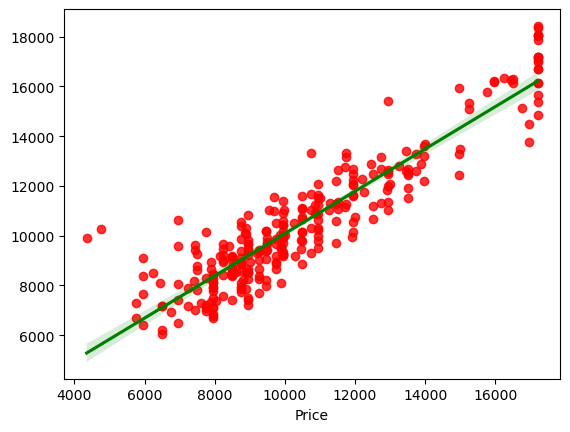

In [36]:
sns.regplot(x=y_test,y=y_pred1,scatter_kws={'color':'red'},line_kws={'color':'green'})
plt.show()

## Lasso

In [132]:
from sklearn.linear_model import Lasso,LassoCV, Ridge

In [134]:
lasso = Lasso(alpha=1.0,max_iter=1000)
lasso.fit(x_train,y_train)
y_pred = lasso.predict(x_test)
r2_score(y_test,y_pred)

0.847012983971739

In [135]:
lassocv = LassoCV(n_alphas=100,max_iter=1000,cv=5)
lassocv.fit(x_train,y_train)

,eps,0.001
,n_alphas,100
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [141]:
lasso.coef_

array([-1962.81856602,  -523.5240792 ,   306.25238109,     0.        ,
        -371.3451344 ,   -79.46065605,     0.        ,     0.        ,
         962.20123968,  -583.21665832,     0.        ,   267.07326843])

In [136]:
best_alpha = lassocv.alpha_
best_alpha

np.float64(2.682369573623665)

In [137]:
mcve = lassocv.mse_path_.mean(axis=1)
mcve

array([8899975.93224977, 8039204.72870626, 7221830.45624127,
       6510925.82759477, 5892622.67257326, 5354859.19046261,
       4887144.66681714, 4480354.83624174, 4126553.899488  ,
       3818839.72310568, 3551209.20209146, 3318441.15927806,
       3115994.49727952, 2939919.61632633, 2786781.37008972,
       2653592.05665547, 2537155.11917114, 2433509.54722014,
       2334635.43261537, 2236533.23302871, 2149767.50555145,
       2070960.63680841, 1990383.81372531, 1912790.34468287,
       1835742.37078388, 1768705.7097221 , 1710380.98126905,
       1658941.91358725, 1611305.99058102, 1569937.28088415,
       1532019.94241916, 1496591.7372318 , 1465766.93640173,
       1438942.85033104, 1415603.8588202 , 1395289.94059555,
       1377611.16252296, 1362225.05403995, 1348833.66757196,
       1337175.53128102, 1327029.56080006, 1318197.90839462,
       1310512.77274456, 1303819.05488184, 1297990.99720852,
       1292916.31688712, 1288497.27314721, 1284646.77829406,
       1280153.66829336,

In [138]:
lasso =Lasso(alpha=best_alpha, max_iter=1000)
lasso.fit(x_train,y_train)
y_pred = lasso.predict(x_test)
r2_score(y_test,y_pred)

0.8466908799600898

## Ridge

In [139]:
ridge = Ridge(alpha=1,max_iter=1000)
ridge.fit(x_train,y_train)
y_test = ridge.predict(x_test)
r2_score(y_test,y_pred)

0.9999258620613389

In [140]:
ridge.coef_

array([-1956.79844197,  -517.6317338 ,   342.03576363,     0.        ,
        -418.3258655 ,   -86.08615693,     0.        ,     0.        ,
         980.68185941,  -651.47731589,   256.789419  ,   394.68789689])

In [142]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(alphas=(0.1,1.0,10.0))
ridgecv.fit(x_train,y_train)
ridgecv.coef_

array([-1941.88771363,  -538.01873506,   295.8608833 ,     0.        ,
        -354.28162836,   -78.87949956,     0.        ,     0.        ,
         959.72166281,  -408.41602769,    54.7980753 ,   353.61795238])

## Model 2

In [39]:
df.head()

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500.0,23.0,46986.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
1,13750.0,23.0,72937.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
2,13950.0,24.0,41711.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
3,14950.0,26.0,48000.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
4,13750.0,30.0,38500.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5


In [66]:
target = df['Price']
features = df.drop(columns=['Price','Automatic','Cylinders','Gears'])

In [68]:
features.head()

,Age,KM,Fuel_Type,HP,cc,Doors,Weight
0,23.0,46986.0,Diesel,90.0,1900.0,3,1152.5
1,23.0,72937.0,Diesel,90.0,1900.0,3,1152.5
2,24.0,41711.0,Diesel,90.0,1900.0,3,1152.5
3,26.0,48000.0,Diesel,90.0,1900.0,3,1152.5
4,30.0,38500.0,Diesel,90.0,1900.0,3,1152.5


In [69]:
x_train2,x_test2,y_train2,y_test2 = train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train2.shape)
print(x_test2.shape)
print(y_train2.shape)
print(y_test2.shape)

(1148, 7)
(287, 7)
(1148,)
(287,)


In [70]:
## Scaling
x_train2[['Age','KM','HP','cc','Doors','Weight']] = std_sca.fit_transform(x_train2[['Age','KM','HP','cc','Doors','Weight']])

In [71]:
x_train2.head()

,Age,KM,Fuel_Type,HP,cc,Doors,Weight
108,-1.940533,-1.748188,Petrol,0.689004,0.255237,-1.074130,0.954608
1280,1.182405,0.176456,Petrol,-1.123604,-1.492799,-0.024682,-1.387370
858,0.320905,-0.079609,Petrol,0.689004,0.255237,1.024766,0.173948
903,0.482436,-0.247509,Petrol,0.689004,0.255237,1.024766,0.173948
373,-1.240564,-1.478104,Petrol,-0.292825,-0.910121,1.024766,0.434168


In [72]:
x_test2[['Age','KM','HP','cc','Doors','Weight']] = std_sca.fit_transform(x_test2[['Age','KM','HP','cc','Doors','Weight']])

In [73]:
x_test2.head()

,Age,KM,Fuel_Type,HP,cc,Doors,Weight
57,-1.626291,-0.706386,Petrol,-0.390378,-1.067253,0.980056,1.172663
1003,0.338264,-0.819226,Petrol,0.633164,0.212015,0.980056,0.163159
361,-1.135152,-1.242067,Petrol,-0.390378,-1.067253,-1.126881,-1.278991
904,0.283693,-0.255024,Petrol,0.633164,0.212015,0.980056,0.018944
1277,1.265971,0.170751,Petrol,0.633164,0.212015,0.980056,0.163159


In [74]:
## Labelling
x_train2 = pd.get_dummies(x_train2,dtype='int')
x_train2.head()

,Age,KM,HP,cc,Doors,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
108,-1.940533,-1.748188,0.689004,0.255237,-1.074130,0.954608,0,0,1
1280,1.182405,0.176456,-1.123604,-1.492799,-0.024682,-1.387370,0,0,1
858,0.320905,-0.079609,0.689004,0.255237,1.024766,0.173948,0,0,1
903,0.482436,-0.247509,0.689004,0.255237,1.024766,0.173948,0,0,1
373,-1.240564,-1.478104,-0.292825,-0.910121,1.024766,0.434168,0,0,1


In [75]:
x_test2 = pd.get_dummies(x_test2,dtype='int')
x_test2.head()

,Age,KM,HP,cc,Doors,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
57,-1.626291,-0.706386,-0.390378,-1.067253,0.980056,1.172663,0,0,1
1003,0.338264,-0.819226,0.633164,0.212015,0.980056,0.163159,0,0,1
361,-1.135152,-1.242067,-0.390378,-1.067253,-1.126881,-1.278991,0,0,1
904,0.283693,-0.255024,0.633164,0.212015,0.980056,0.018944,0,0,1
1277,1.265971,0.170751,0.633164,0.212015,0.980056,0.163159,0,0,1


In [76]:
## Linear Regression
line_reg = LinearRegression()
line_reg.fit(x_train2,y_train2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [77]:
line_reg.coef_

array([-1957.81107643,  -514.52267639,   356.24807781,  -435.49800766,
         -86.69463803,   983.10100714,  -705.32574636,   312.87997671,
         392.44576965])

In [78]:
line_reg.intercept_

np.float64(10118.485872634768)

In [79]:
## Train validation
y_pred2 = line_reg.predict(x_train2)
r2_score(y_train2,y_pred2)

0.8691098922833208

In [80]:
## Test validation
y_pred22 = line_reg.predict(x_test2)
r2_score(y_test2,y_pred22)

0.8471691854179333

In [124]:
mae = mean_absolute_error(y_train2, y_pred2)
mae

828.1534503237267

In [123]:
mae = mean_absolute_error(y_test2, y_pred22)
mae

839.1537716498102

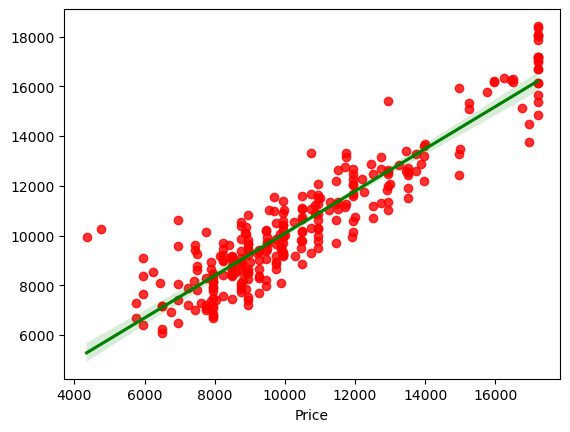

In [81]:
sns.regplot(x=y_test,y=y_pred1,scatter_kws={'color':'red'},line_kws={'color':'green'})
plt.show()

## Model 3


In [82]:
df.head()

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500.0,23.0,46986.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
1,13750.0,23.0,72937.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
2,13950.0,24.0,41711.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
3,14950.0,26.0,48000.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
4,13750.0,30.0,38500.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5


In [99]:
target3 = df['Price']
features3 = df.drop(columns=['Price','Automatic','Cylinders','Gears','HP'])

In [100]:
features3.head()

,Age,KM,Fuel_Type,cc,Doors,Weight
0,23.0,46986.0,Diesel,1900.0,3,1152.5
1,23.0,72937.0,Diesel,1900.0,3,1152.5
2,24.0,41711.0,Diesel,1900.0,3,1152.5
3,26.0,48000.0,Diesel,1900.0,3,1152.5
4,30.0,38500.0,Diesel,1900.0,3,1152.5


In [101]:
x_train3,x_test3,y_train3,y_test3 = train_test_split(features3,target3,train_size=0.8,random_state=100)
print(x_train3.shape)
print(x_test3.shape)
print(y_train3.shape)
print(y_test3.shape)

(1148, 6)
(287, 6)
(1148,)
(287,)


In [102]:
## Scaling
x_train3[['Age','KM','cc','Doors','Weight']] = std_sca.fit_transform(x_train3[['Age','KM','cc','Doors','Weight']])

In [103]:
x_train3.head()

,Age,KM,Fuel_Type,cc,Doors,Weight
108,-1.940533,-1.748188,Petrol,0.255237,-1.074130,0.954608
1280,1.182405,0.176456,Petrol,-1.492799,-0.024682,-1.387370
858,0.320905,-0.079609,Petrol,0.255237,1.024766,0.173948
903,0.482436,-0.247509,Petrol,0.255237,1.024766,0.173948
373,-1.240564,-1.478104,Petrol,-0.910121,1.024766,0.434168


In [104]:
x_test3[['Age','KM','cc','Doors','Weight']] = std_sca.fit_transform(x_test3[['Age','KM','cc','Doors','Weight']])

In [105]:
x_test3.head()

,Age,KM,Fuel_Type,cc,Doors,Weight
57,-1.626291,-0.706386,Petrol,-1.067253,0.980056,1.172663
1003,0.338264,-0.819226,Petrol,0.212015,0.980056,0.163159
361,-1.135152,-1.242067,Petrol,-1.067253,-1.126881,-1.278991
904,0.283693,-0.255024,Petrol,0.212015,0.980056,0.018944
1277,1.265971,0.170751,Petrol,0.212015,0.980056,0.163159


In [106]:
## Labelling
x_train3 = pd.get_dummies(x_train3,dtype='int')
x_train3.head()

,Age,KM,cc,Doors,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
108,-1.940533,-1.748188,0.255237,-1.074130,0.954608,0,0,1
1280,1.182405,0.176456,-1.492799,-0.024682,-1.387370,0,0,1
858,0.320905,-0.079609,0.255237,1.024766,0.173948,0,0,1
903,0.482436,-0.247509,0.255237,1.024766,0.173948,0,0,1
373,-1.240564,-1.478104,-0.910121,1.024766,0.434168,0,0,1


In [107]:
x_test3 = pd.get_dummies(x_test3,dtype='int')
x_test3.head()

,Age,KM,cc,Doors,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
57,-1.626291,-0.706386,-1.067253,0.980056,1.172663,0,0,1
1003,0.338264,-0.819226,0.212015,0.980056,0.163159,0,0,1
361,-1.135152,-1.242067,-1.067253,-1.126881,-1.278991,0,0,1
904,0.283693,-0.255024,0.212015,0.980056,0.018944,0,0,1
1277,1.265971,0.170751,0.212015,0.980056,0.163159,0,0,1


In [108]:
## Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(x_train3,y_train3)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [109]:
lin_reg.coef_

array([-1978.54228534,  -541.82815256,   -81.10636052,   -92.59661067,
         996.90098958,  -202.40617949,  -671.31080558,   873.71698507])

In [111]:
lin_reg.intercept_

np.float64(9796.517508076951)

In [95]:
## The price drops after removing the column Doors

In [112]:
## Train validation
y_pred3 = lin_reg.predict(x_train3)
r2_score(y_train3,y_pred3)

0.8676671828516728

In [113]:
## Test validation
y_pred33 = lin_reg.predict(x_test3)
r2_score(y_test3,y_pred33)

0.8442246419854382

In [125]:
mae = mean_absolute_error(y_train3, y_pred3)
mae

829.4266734298275

In [126]:
mae = mean_absolute_error(y_test3, y_pred33)
mae

846.1065400223376